## 3. EDA: Limpieza y Transformacion

In [1]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### 3.1 Cargar los datos

In [2]:
df = pd.read_csv('../data/processed/dataset_ma_ml_final.csv')
print(df.shape)
df.head()

(5071, 51)


,costat,curcd,datafmt,indfmt,consol,tic,datadate,gvkey,conm,exchg,...,ebitda_margin,net_margin,leverage,capex_intensity,roa,current_ratio,market_cap,ev_ebitda,asset_turnover,cash_ratio
0,I,USD,STD,INDL,C,BLS,2005-12-31,2146,BELLSOUTH CORP,11.0,...,0.393877,0.160315,0.303927,0.168248,0.058246,-0.134619,48725.80000,6.020734,0.363323,0.007550
1,I,USD,STD,INDL,C,CELG,2018-12-31,13599,CELGENE CORP,14.0,...,0.464498,0.264773,0.571308,0.021595,0.114036,0.170879,44875.81800,6.322319,0.430693,0.170293
2,I,USD,STD,INDL,C,TWC,2015-12-31,176404,TIME WARNER CABLE INC,11.0,...,0.343419,0.077816,0.456643,0.187619,0.037421,-0.036993,52577.64700,6.460758,0.480894,0.023743
3,I,USD,STD,INDL,C,AET,2017-12-31,1177,AETNA INC,11.0,...,0.089798,0.031499,0.166071,0.006783,0.034523,-0.033423,58951.45200,10.860621,1.096027,0.112237
4,I,USD,STD,INDL,C,WYE,2008-12-31,1478,WYETH,11.0,...,0.348333,0.193477,0.266609,0.061706,0.100333,0.669040,49946.59054,6.279582,0.518579,0.330336


### 3.2 Analisis Exploratorio (EDA)

#### 3.21 Procesamiento valores nulos

In [3]:
df.info()
df.describe()
total_NaN = df.isnull().sum().sum()
print("\nTotal valores nulos: {}".format(total_NaN))

<class 'pandas.DataFrame'>
RangeIndex: 5071 entries, 0 to 5070
Data columns (total 51 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   costat              5071 non-null   str    
 1   curcd               5071 non-null   str    
 2   datafmt             5071 non-null   str    
 3   indfmt              5071 non-null   str    
 4   consol              5071 non-null   str    
 5   tic                 5071 non-null   str    
 6   datadate            5071 non-null   str    
 7   gvkey               5071 non-null   int64  
 8   conm                5071 non-null   str    
 9   exchg               5071 non-null   float64
 10  fyear               5071 non-null   int64  
 11  ap                  5030 non-null   float64
 12  at                  5071 non-null   float64
 13  che                 5070 non-null   float64
 14  dlc                 5062 non-null   float64
 15  dltt                5053 non-null   float64
 16  lt               

Hay muchos valores nulos entonces vamos a identificar el porcentaje por variable.

In [4]:
pd.set_option('display.max_rows', None)
nulos = df.isnull().mean() * 100
nulos = nulos[nulos > 0].sort_values(ascending=False)
print(nulos.round(2))

deal_type2            95.82
pb_industry_group     68.92
pb_industry_sector    68.92
pb_investors          68.88
deal_size             68.66
deal_date             68.66
pb_company            68.66
match_score           68.66
current_ratio         20.47
wcap                  20.23
xsga                  16.68
market_cap             9.68
prcc_f                 9.47
dp                     4.32
sich                   3.45
ebitda                 3.39
oibdp                  3.39
capex_intensity        2.72
capx                   2.72
csho                   2.50
pb_industry_code       2.45
ap                     0.81
rect                   0.69
dltt                   0.35
lt                     0.20
dlc                    0.18
che                    0.02
cash_ratio             0.02
dtype: float64


El dataset combina dos grupos de empresas: el 25% son empresas que fueron adquiridas (ma_target = 1) y el 75% restante son empresas del universo Compustat que nunca lo fueron (ma_target = 0). Las columnas pb_ y deal_ como deal_date, deal_size o pb_company solo tienen datos para ese 25%, no porque haya errores de datos, sino porque esos campos solo existen cuando hubo un deal real. Por eso aparecen con un 75% de nulos. Estas variables no entran al modelo porque son información posterior al evento que queremos predecir. Usarlas sería hacer trampa. Se guardan únicamente para dar contexto en el dashboard.

In [5]:
# Columnas de contexto/dashboard (no entran al modelo)
cols_contexto = ['pb_company', 'deal_date', 'deal_size', 'deal_type2', 
                 'match_score', 'pb_industry_code', 'pb_investors', 
                 'pb_industry_sector', 'pb_industry_group']

# Guardar df completo para el dashboard
df_dashboard = df.copy()

# Dataset para el modelo (sin columnas de PitchBook de deals)
df_modelo = df.drop(columns=cols_contexto)

print("df_modelo shape:", df_modelo.shape)
print("Nulos restantes:")
print((df_modelo.isnull().mean() * 100).round(2).sort_values(ascending=False))

df_modelo shape: (5071, 42)
Nulos restantes:
current_ratio      20.47
wcap               20.23
xsga               16.68
market_cap          9.68
prcc_f              9.47
dp                  4.32
sich                3.45
ebitda              3.39
oibdp               3.39
capx                2.72
capex_intensity     2.72
csho                2.50
ap                  0.81
rect                0.69
dltt                0.35
lt                  0.20
dlc                 0.18
che                 0.02
cash_ratio          0.02
costat              0.00
curcd               0.00
datadate            0.00
tic                 0.00
consol              0.00
indfmt              0.00
datafmt             0.00
exchg               0.00
conm                0.00
gvkey               0.00
fyear               0.00
sale                0.00
ni                  0.00
at                  0.00
company_clean       0.00
net_margin          0.00
ebitda_margin       0.00
total_debt          0.00
ma_target           0.00
roa  

Vamos a ver qué pasaría si eliminamos los datos nulos: si se eliminarían muchas o pocas filas y en función de eso decidimos dropear los valores nulos o imputar

In [6]:
# Ver cuántas filas quedarían si eliminamos todas las que tienen algún nulo
print("Filas actuales:", len(df_modelo))
print("Filas sin ningún nulo:", len(df_modelo.dropna()))
print("Filas perdidas:", len(df_modelo) - len(df_modelo.dropna()))
print()
# Ver cuántos nulos tiene cada fila
df_modelo['n_nulos'] = df_modelo.isnull().sum(axis=1)
print(df_modelo['n_nulos'].value_counts().sort_index().head(15))

Filas actuales: 5071
Filas sin ningún nulo: 3160
Filas perdidas: 1911

n_nulos
0     3160
1      395
2      675
3      439
4      115
5      156
6      103
7       16
8        9
9        1
10       1
14       1
Name: count, dtype: int64


Perderíamos muchas filas con un dropna directo y sería una pena perder las variables que solo tienen 1-2 valores nulos y las filas que tienen más de 6 valores nulos son pocas con respecto al número total de filas. 

Entonces, el procedimiento a seguir va a ser el siguiente: 
1. Eliminar las filas con +6 valores nulos
2. Evaluar los outliers de las variables y tratarlos
3. Imputar los valores nulos restantes por la mediana en vez de usar la media porque la media puede distorsionar el dataset debido a posibles outliers, mientras que la mediana representa mejor al grupo típico

#### 3.211 Eliminación valores nulos graves

In [7]:
# Eliminar filas con 6 o más nulos
df_modelo = df_modelo[df_modelo['n_nulos'] < 6]

print("Filas después:", len(df_modelo))
print("Targets conservados:", df_modelo['ma_target'].sum())
print("No targets:", (df_modelo['ma_target'] == 0).sum())
print()

Filas después: 4940
Targets conservados: 1552
No targets: 3388



Bien, perdemos 177 targets (10%) y el ratio sigue siendo aproximadamente 1:2.2 (targets vs no targets), que está bien para el modelo

#### 3.212 Evaluación de outliers

##### Boxplots para visualizar los outliers

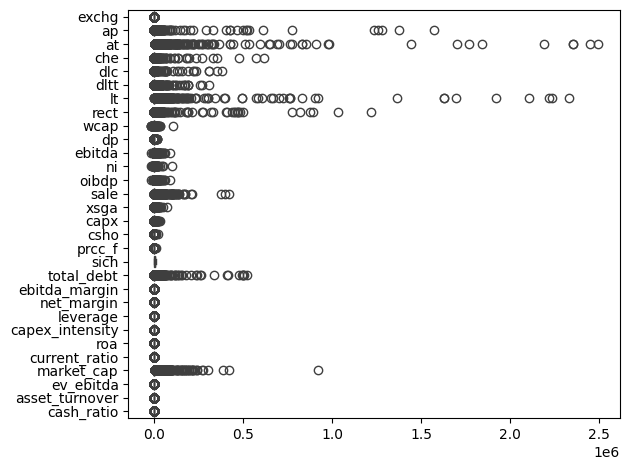

In [8]:
# Boxplot de todas las variables numéricas como en clase
cols_num = df_modelo.select_dtypes(include='number').columns.tolist()
cols_num = [c for c in cols_num if c not in ['ma_target', 'gvkey', 'fyear', 'n_nulos']]

df_num = df_modelo[cols_num]

sns.boxplot(data=df_num, orient='h')
plt.tight_layout()
plt.show()

Tenemos que normalizar los datos primero para que estén todos en una misma escala de 0-1 y podamos evaluar el impacto de los outliers

##### Normalización de los datos

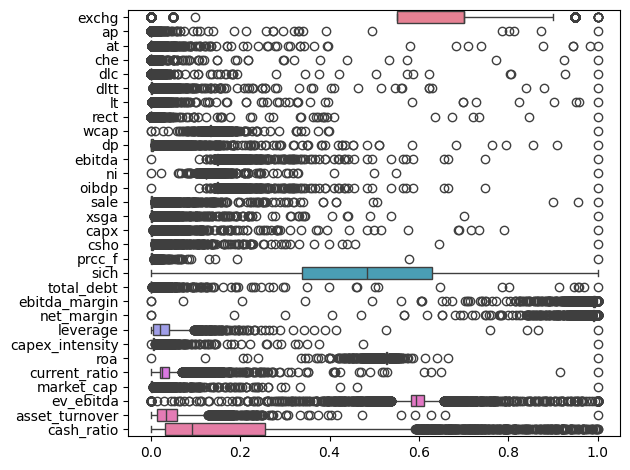

Variable: exchg
Max: 20.00
Min: 0.00
Median: 14.00
 
Variable: ap
Max: 1574020.17
Min: 0.00
Median: 26.30
 
Variable: at
Max: 2490972.00
Min: 1.05
Median: 588.04
 
Variable: che
Max: 619602.00
Min: 0.00
Median: 50.23
 
Variable: dlc
Max: 382407.00
Min: 0.00
Median: 4.60
 
Variable: dltt
Max: 308504.00
Min: 0.00
Median: 50.46
 
Variable: lt
Max: 2332384.20
Min: 0.00
Median: 322.58
 
Variable: rect
Max: 1218914.00
Min: 0.00
Median: 65.52
 
Variable: wcap
Max: 107357.00
Min: -16331.33
Median: 47.84
 
Variable: dp
Max: 19960.97
Min: 0.00
Median: 12.13
 
Variable: ebitda
Max: 93265.92
Min: -16103.00
Median: 35.72
 
Variable: ni
Max: 104821.00
Min: -14685.00
Median: 6.99
 
Variable: oibdp
Max: 93265.92
Min: -16103.00
Median: 35.72
 
Variable: sale
Max: 420714.00
Min: 1.01
Median: 290.94
 
Variable: xsga
Max: 76299.00
Min: -16.52
Median: 62.25
 
Variable: capx
Max: 34271.00
Min: -0.56
Median: 9.27
 
Variable: csho
Max: 21974.65
Min: 0.00
Median: 34.03
 
Variable: prcc_f
Max: 10300.00
Min: 0.0

In [9]:
from sklearn.preprocessing import MinMaxScaler

# Columnas numéricas (excluimos identificadores y la variable objetivo)
cols_num = df_modelo.select_dtypes(include='number').columns.tolist()
cols_num = [c for c in cols_num if c not in ['ma_target', 'gvkey', 'fyear', 'n_nulos']]

# Normalizar Min-Max solo las financieras
scaler = MinMaxScaler()
df_normalized = df_modelo.copy()
df_normalized[cols_num] = scaler.fit_transform(df_modelo[cols_num])

# Boxplot conjunto - ahora todas en la misma escala (0-1)
sns.boxplot(data=df_normalized[cols_num], orient='h')
plt.tight_layout()
plt.show()

# Max, min y mediana de cada variable
for a in cols_num:
    print(f'Variable: {a}')
    print(f'Max: {df_modelo[a].max():.2f}')
    print(f'Min: {df_modelo[a].min():.2f}')
    print(f'Median: {df_modelo[a].median():.2f}')
    print(' ')

· Variables de tamaño absoluto (at, sale, market_cap, lt, total_debt...): todas tienen la caja aplastada cerca del 0 con muchos outliers a la derecha. Es completamente normal en datos financieros — hay pocas empresas gigantes (Apple, ExxonMobil) y muchas medianas. Esto no es un problema pero confirma que normalizar antes del modelo es imprescindible.

· ebitda_margin y net_margin: la caja está desplazada hacia la derecha (valores positivos) con outliers negativos a la izquierda. Corresponde a empresas en pérdidas (biotechs, startups) que ya analizamos, es real y esperado.

· sich y exchg: son códigos numéricos (sector SIC y bolsa), no variables continuas. La caja ocupa todo el rango porque los códigos están distribuidos uniformemente. Habrá que tratarlos como variables categóricas o directamente excluirlos del modelo.

· ev_ebitda: sigue teniendo un rango amplio (-145 a 108) incluso después de winsorizarla, con la caja cerca del centro. Es la variable más ruidosa del dataset y habrá que monitorizar su importancia en el modelo.

· cash_ratio y asset_turnover: distribuciones muy distintas entre sí pero ambas con rangos razonables tras el filtrado. Son ratios relevantes para M&A ya que empresas con mucha caja o alta eficiencia operativa son atractivas como targets.

En este gráfico estamos viendo muchos outliers así a primera vista entonces toca evaluar si tiene sentido conforme a la variable y el contexto del proyecto o si es un error/ no tiene sentido y debemos acotar la variable o eliminarla directamente

In [10]:
vars_revisar = ['ebitda_margin', 'net_margin', 'roa', 'ev_ebitda', 
                'leverage', 'capex_intensity', 'asset_turnover']

for col in vars_revisar:
    print(f'--- {col} ---')
    print(f'  Min:    {df_modelo[col].min():.2f}')
    print(f'  Max:    {df_modelo[col].max():.2f}')
    print(f'  Median: {df_modelo[col].median():.2f}')
    print()

--- ebitda_margin ---
  Min:    -66.74
  Max:    0.72
  Median: 0.12

--- net_margin ---
  Min:    -79.69
  Max:    0.70
  Median: 0.04

--- roa ---
  Min:    -13.94
  Max:    12.50
  Median: 0.02

--- ev_ebitda ---
  Min:    -145.42
  Max:    108.82
  Median: 5.42

--- leverage ---
  Min:    0.00
  Max:    9.44
  Median: 0.19

--- capex_intensity ---
  Min:    -0.08
  Max:    23.20
  Median: 0.03

--- asset_turnover ---
  Min:    0.00
  Max:    19.37
  Median: 0.65



In [11]:
# Ver qué empresas tienen los valores más extremos
vars_revisar = ['ebitda_margin', 'net_margin', 'roa', 'ev_ebitda', 
                'leverage', 'capex_intensity', 'asset_turnover']

for col in vars_revisar:
    print(f'\n--- {col} - Top 5 valores más extremos ---')
    extremos = df_modelo[['conm', 'fyear', 'ma_target', col]].nsmallest(5, col)
    print(extremos.to_string())
    print(f'--- Top 5 valores más altos ---')
    extremos2 = df_modelo[['conm', 'fyear', 'ma_target', col]].nlargest(5, col)
    print(extremos2.to_string())


--- ebitda_margin - Top 5 valores más extremos ---
                           conm  fyear  ma_target  ebitda_margin
1075  NORTHWEST BIOTHERAPEUTICS   2014          1     -66.738739
1695   SAREPTA THERAPEUTICS INC   2015          0     -66.738739
75               PHARMASSET INC   2010          1     -61.928431
1780            FUNCTION(X) INC   2012          0     -52.926225
1769               REGENETP INC   2018          0     -43.429303
--- Top 5 valores más altos ---
                           conm  fyear  ma_target  ebitda_margin
13               XTO ENERGY INC   2009          1       0.723258
126               AIRCASTLE LTD   2019          1       0.723258
127                       PIXAR   2005          1       0.723258
172           ATHLON ENERGY INC   2013          1       0.723258
355  KKR FINANCIAL HOLDINGS LLC   2013          1       0.723258

--- net_margin - Top 5 valores más extremos ---
                              conm  fyear  ma_target  net_margin
1075     NORTHWEST BIO

No hay más errores de datos, son características reales de estas empresas. Los valores extremos están justificados por el sector y modelo de negocio. La winsorización al 1% que ya aplicamos es suficiente.

#### 3.213 Imputación

La imputación por mediana es más adecuada que dropna() en este caso porque las variables financieras tienen distribuciones asimétricas con outliers, donde la mediana representa mejor el valor típico de una empresa que la media. Además, conservamos todas las filas en lugar de perderlas por tener un solo dato missing.

In [12]:
# Imputación de nulos restantes con la mediana de cada variable
# Se usa la mediana por ser más robusta que la media ante outliers en datos financieros

cols_financieras = df_modelo.select_dtypes(include='number').columns.tolist()
cols_financieras = [c for c in cols_financieras if c not in ['ma_target', 'gvkey', 'fyear', 'n_nulos']]

for col in cols_financieras:
    if df_modelo[col].isnull().any():
        mediana = df_modelo[col].median()
        df_modelo[col] = df_modelo[col].fillna(mediana)

print("Nulos restantes:", df_modelo.isnull().sum().sum())
print("Filas conservadas:", len(df_modelo))
print("Targets conservados:", df_modelo['ma_target'].sum())

Nulos restantes: 0
Filas conservadas: 4940
Targets conservados: 1552


### 3.3 Relaciones entre variables

#### 3.31 Pairplots y Heatmap

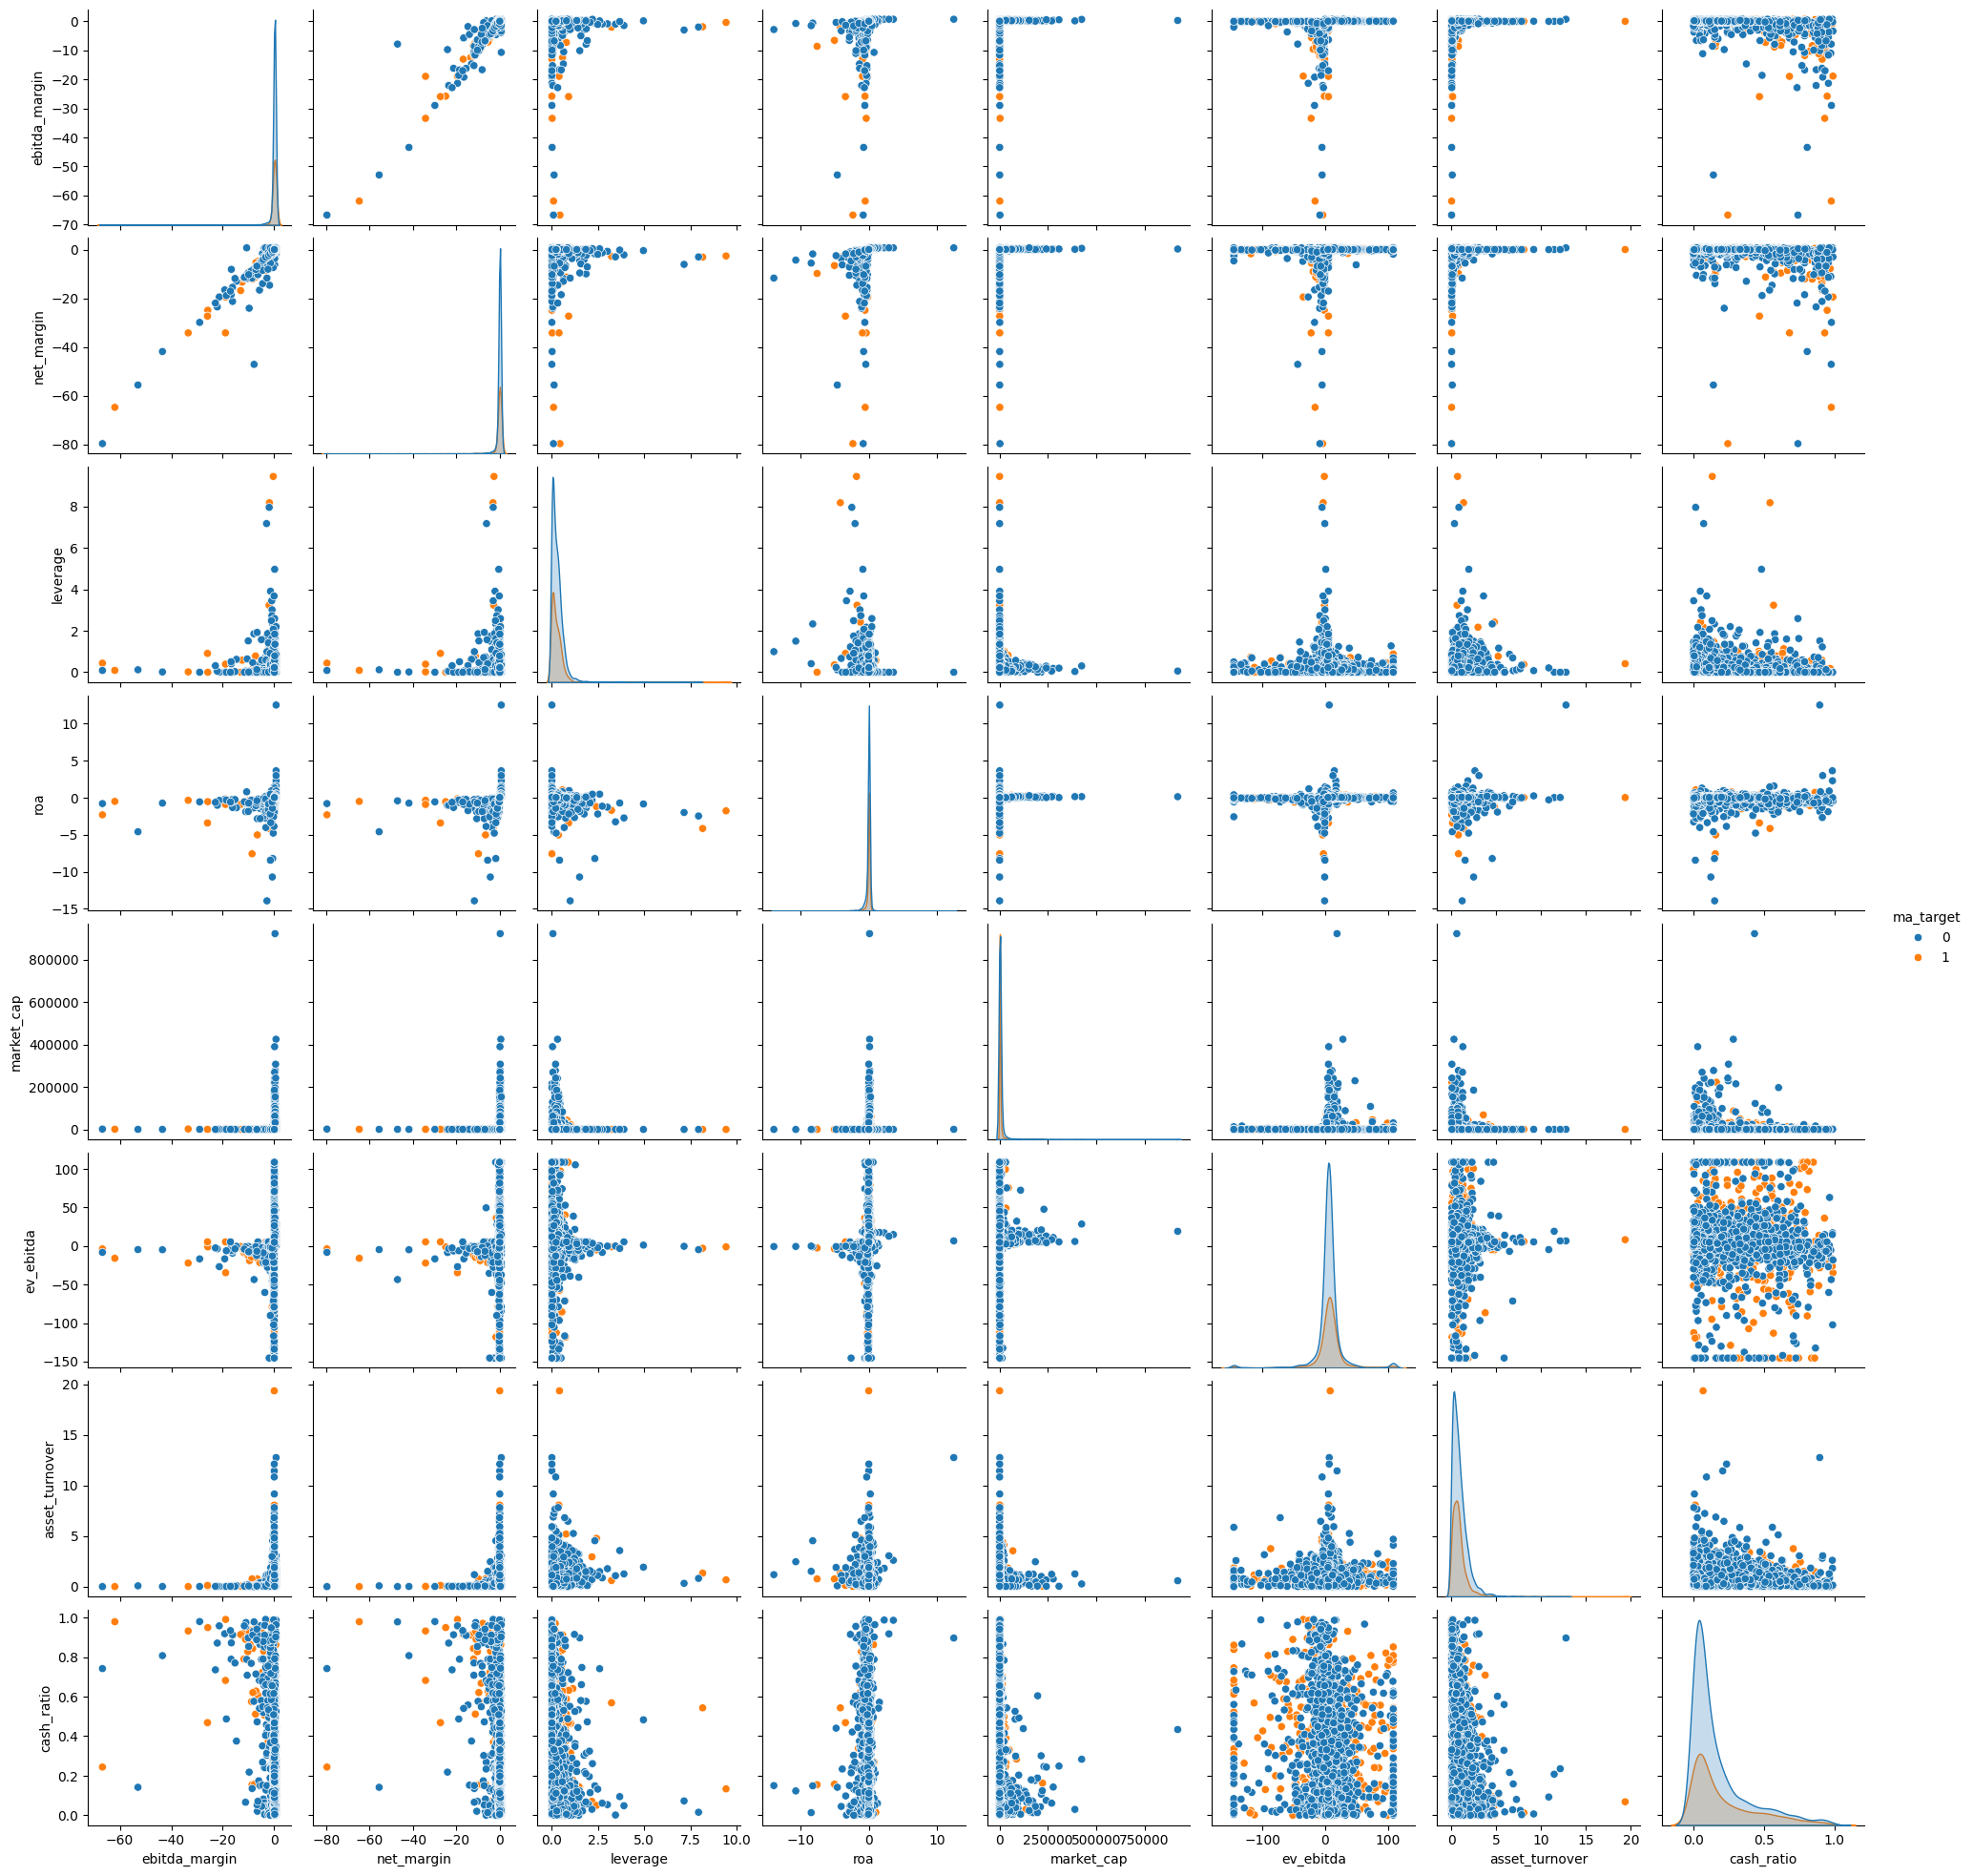

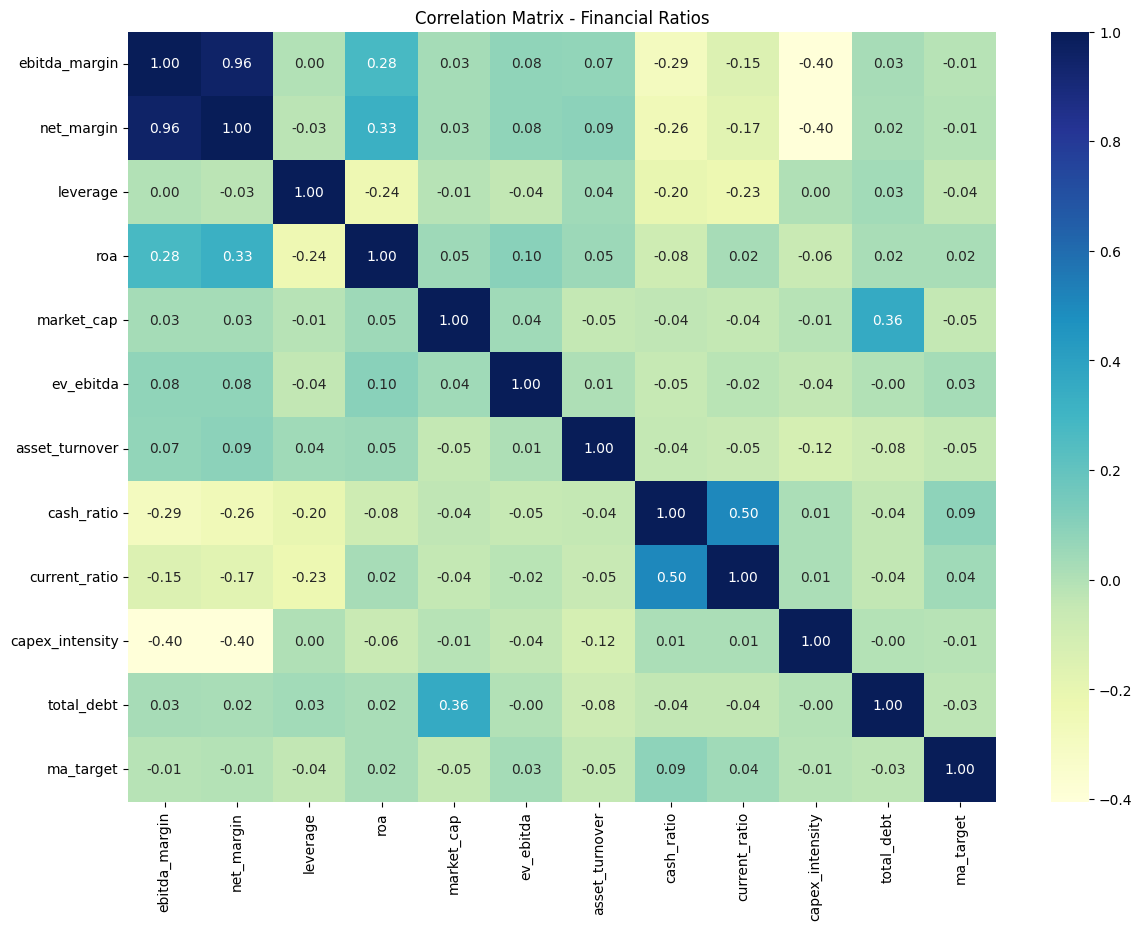

In [15]:
# Pairplot simple
# Pairplot con las variables más relevantes para M&A
vars_pairplot = ['ebitda_margin', 'net_margin', 'leverage', 'roa', 
                 'market_cap', 'ev_ebitda', 'asset_turnover', 'cash_ratio', 'ma_target']

sns.pairplot(df_modelo[vars_pairplot], hue='ma_target')
plt.show()

#Heatmap de correlaciones
vars_heatmap = ['ebitda_margin', 'net_margin', 'leverage', 'roa', 
                'market_cap', 'ev_ebitda', 'asset_turnover', 'cash_ratio',
                'current_ratio', 'capex_intensity', 'total_debt', 'ma_target']

plt.figure(figsize=(14, 10))
sns.heatmap(df_modelo[vars_heatmap].corr(), 
            cmap="YlGnBu", annot=True, fmt='.2f')
plt.title('Correlation Matrix - Financial Ratios')
plt.show()

Conclusiones:
- market_cap y total_debt tienen correlación 0.36 lo cual tiene sentido, empresas más grandes tienen más deuda absoluta 
- Dado que ninguna variable correlaciona fuerte con ma_target, el modelo va a necesitar capturar interacciones entre variables, lo que favorece modelos no lineales como Random Forest o Gradient Boosting sobre una simple regresión logística
- ebitda_margin y net_margin tienen correlación 0.96. Son casi la misma variable, entonces habría que considerar eliminar una de las dos antes del modelo
- net_margin y ebitda_margin tienen correlación 0.96. Se considerará eliminar net_margin en la selección de features del modelo dado que ebitda_margin es más relevante en el contexto de M&A y ambas variables absolutas (ebitda, ni) ya están presentes en el dataset

In [18]:
df_modelo = df_modelo.drop(columns=['net_margin'])
print("Columnas restantes:", df_modelo.shape[1])

Columnas restantes: 42


#### 3.32 VIFs (multicolinealidad)

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)

vif_data = pd.DataFrame()
vif_data["feature"] = X_train_df.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_df.values.astype(float), i)
                   for i in range(len(X_train_df.columns))]

print(vif_data.sort_values('VIF', ascending=False).to_string())

            feature           VIF
10           ebitda           inf
12            oibdp           inf
19       total_debt  6.572028e+07
5              dltt  2.011813e+07
4               dlc  1.654214e+07
2                at  4.645681e+02
6                lt  4.121579e+02
7              rect  2.298609e+01
1                ap  1.946828e+01
3               che  1.493838e+01
9                dp  9.632968e+00
15             capx  8.804863e+00
21       net_margin  7.941018e+00
20    ebitda_margin  7.762432e+00
26       market_cap  6.318855e+00
13             sale  5.235323e+00
14             xsga  3.282408e+00
16             csho  2.400045e+00
8              wcap  2.139725e+00
11               ni  1.668467e+00
29       cash_ratio  1.572201e+00
25    current_ratio  1.540687e+00
24              roa  1.266714e+00
22         leverage  1.233728e+00
23  capex_intensity  1.125692e+00
28   asset_turnover  1.088623e+00
0             exchg  1.086133e+00
17           prcc_f  1.056060e+00
18            

Conclusiones:
- ebitda y oibdp --> VIF infinito significa que son perfectamente colineales entre sí. Eliminamos oibdp y nos quedamos con ebitda
- VIFs altos: total_debt --> 65M, es simplemente dltt + dlc, que ya están en el modelo y dltt y dlc también muy altos, pero son los componentes de total_debt, luego nos quedamos con total_debt y eliminamos dltt y dlc

### 3.4 Transformaciones

#### 3.41 Identificar variables cualitativas y crear dummies

In [22]:
qualitative_vars = df_modelo.select_dtypes(include=['object']).columns
print("Variables cualitativas:", qualitative_vars.tolist())

Variables cualitativas: ['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate', 'conm', 'company_clean']


#### 3.42 Estandarización

Columnas restantes: ['exchg', 'ap', 'at', 'che', 'lt', 'rect', 'wcap', 'dp', 'ebitda', 'ni', 'sale', 'xsga', 'capx', 'csho', 'prcc_f', 'sich', 'total_debt', 'ebitda_margin', 'leverage', 'capex_intensity', 'roa', 'current_ratio', 'market_cap', 'ev_ebitda', 'asset_turnover', 'cash_ratio']


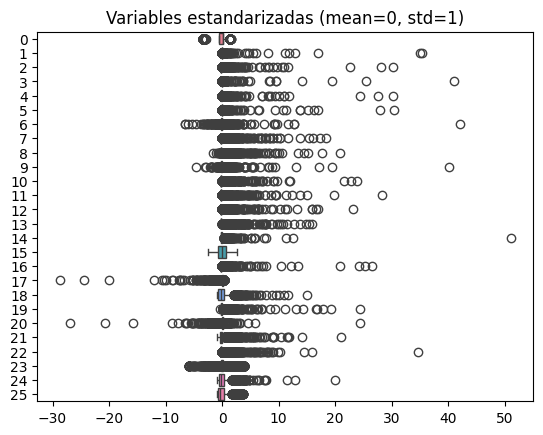

In [23]:
# Shuffle de los datos
df_modelo = df_modelo.drop(columns=['oibdp', 'dltt', 'dlc', 'net_margin'], errors='ignore')

df_shuffled = df_modelo.sample(frac=1, random_state=1234)

y = df_shuffled['ma_target']
X = df_shuffled.drop(['ma_target', 'gvkey', 'fyear', 'n_nulos',
                      'costat', 'curcd', 'datafmt', 'indfmt', 'consol',
                      'tic', 'datadate', 'conm', 'company_clean'], axis=1)

print("Columnas restantes:", X.columns.tolist())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
                                        X, y,
                                        train_size=0.7,
                                        random_state=1234,
                                        shuffle=True
                                    )

# Estandarización
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Verificar que ha funcionado
sns.boxplot(data=X_train_scaled, orient='h')
plt.title('Variables estandarizadas (mean=0, std=1)')
plt.show()

#### 3.45 Guardar DF para siguiente paso

In [24]:
# Guardar dataset limpio para el modelaje
import pickle

# Guardar X_train, X_test, y_train, y_test y el scaler
with open('../data/processed/data_splits.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train_scaled,
        'X_test': X_test_scaled,
        'y_train': y_train.values,
        'y_test': y_test.values,
        'feature_names': X.columns.tolist()
    }, f)

# Guardar también el df_modelo limpio
df_modelo.to_csv('../data/processed/dataset_fase3_limpio.csv', index=False)

print("✓ Datos guardados correctamente")
print(f"  X_train: {X_train_scaled.shape}")
print(f"  X_test: {X_test_scaled.shape}")
print(f"  Features: {X.columns.tolist()}")

✓ Datos guardados correctamente
  X_train: (3458, 26)
  X_test: (1482, 26)
  Features: ['exchg', 'ap', 'at', 'che', 'lt', 'rect', 'wcap', 'dp', 'ebitda', 'ni', 'sale', 'xsga', 'capx', 'csho', 'prcc_f', 'sich', 'total_debt', 'ebitda_margin', 'leverage', 'capex_intensity', 'roa', 'current_ratio', 'market_cap', 'ev_ebitda', 'asset_turnover', 'cash_ratio']


La Fase 3 ha preparado el dataset para el modelaje en tres pasos. Primero se separaron las columnas de PitchBook del dataset de modelaje para evitar data leakage. Segundo, se limpiaron los datos eliminando micro-caps con ratios distorsionados, winzorizando variables con valores extremos, eliminando filas con 6+ nulos e imputando el resto con la mediana. Tercero, el análisis de correlaciones y VIFs llevó a eliminar `oibdp`, `net_margin`, `dltt` y `dlc` por multicolinealidad. El dataset final cuenta con 4.940 filas, 26 features, 1.552 targets y ratio 0.31, estandarizado y dividido en train (70%) y test (30%).